This Jupyter Notebook makes use of the `affiliation-builder` package to build an affiliation network from TEI-to-JSON converted `<event>` data. This serves two purposes. First, the Notebook is intended to demonstrate the Python utility in a real-world use case. Second, being run on the XSLT-transformed TEI `<listEvent>` of the [Auden Musulin Papers](https://www.oeaw.ac.at/acdh/research/literary-studies/research/authors-editions/auden-musulin-papers) project (2021-2024), it tentatively outlines the contours of a network-analysis-supported research of British-American poet W. H. Auden's biographical environment during his Austrian period 1957-1973.

Because the data originate in the digital edition of Auden's correspondence with Welsh-Austrian writer Stella Musulin and of her two previously unpublished Auden memoirs, a strong bias, resulting in a tendency toward (over-)emphasizing the memoirist's position in Auden's network, is expected. A less distorted `<listEvent>` dataset is currently being developed in the context of the [Auden in Austria Digital](https://www.oeaw.ac.at/acdh/research/literary-studies/research/authors-editions/auden-in-austria-digital) project (2024-2027), which will provide a solid basis for network research.

#### 1 Install packages

In [1]:
%pip install -q networkx pandas matplotlib affiliation-builder  # line magic for Notebook-kernel installation; install quietly

Note: you may need to restart the kernel to use updated packages.


#### 2 Import dependencies

In [2]:
import logging

# network analysis
import networkx as nx
from networkx.algorithms import bipartite

# data manipulation
import pandas as pd

# visualization
import matplotlib.pyplot as plt

# affiliation-builder
from affiliation_builder import build

#### 3 Configure logging

In [3]:
logging.getLogger('affiliation_builder').setLevel(logging.INFO)  # retrieve package logger; include INFO-level log messages
logging.getLogger('affiliation_builder').addHandler(logging.StreamHandler())  # attach handler for console output

#### 4 Build bipartite network from JSON data

This construction of a bipartite network loads both person and organization data as nodes of the same set. This is done against the background of a research interest in Auden's Austrian environment, understood as comprising both the people and the institutions affiliated with the events in which Auden participated. In the projected (unipartite) network, person-person edges will therefore represent co-attendance; person-organization edges will connect people attending events with institutions identified as organizing or hosting those events; organization-organization edges will map institutional co-affiliation. The metrics calculated further below (density, components, weighted degree) aggregate over all node and edge types.

In [4]:
G_bipartite = build(
    json_path="../examples/amp-events.json",  # JSON data source
    node_set_0_key="listEvent",  # top-level JSON key wrapping events
    node_set_1_keys=["listPerson", "org"],  # JSON keys for affiliated entities
    identifier_key="xml:id",  # JSON key for event ID
    node_set_1_identifier_key="sameAs"  # JSON key for ID of affiliated entity
)

Affiliation network builder started
JSON source: ../examples/amp-events.json
Node-set-0 key: 'listEvent'
Node-set-1 keys: ['listPerson', 'org']
Identifier key: 'xml:id'
Node-set-1 identifier key: 'sameAs'
Local file path detected: ../examples/amp-events.json
Local JSON file successfully loaded
Wrapped object format with 105 items in 'listEvent' detected
NetworkX graph initialized
Bipartite network construction complete
Total edges (affiliations): 245
Total nodes: 188
Node set 0 (listEvent): 105 nodes
Node set 1 (['listPerson', 'org']): 83 nodes
✓ Graph structure is valid bipartite


#### 5 Filter bipartite graph

##### 5.1 Create filter

In [5]:
# Filter by event date

def filter_by_date(G_bipartite, start_date, end_date):
    """
    Filter bipartite graph to events within a date range.
    Uses notBefore-iso attribute for filtering.
    
    Parameters
    ----------
    G_bipartite : networkx.Graph
        Bipartite event-participant graph
    start_date : str
        Start date in ISO format (e.g., '1960-01-01')
    end_date : str
        End date in ISO format (e.g., '1970-12-31')
    
    Returns
    -------
    networkx.Graph
        Filtered bipartite graph
    """
    filtered_events = []  # List to collect relevant event node IDs

    for node, data in G_bipartite.nodes(data=True):  # Loop through all nodes with their IDs and attributes
        if data.get('bipartite') == 0:  # Get events
            event_date = data.get('notBefore-iso', '')[:10]  # Get event start date attribute
            if event_date and start_date <= event_date <= end_date:  # Check event start date is in range
                filtered_events.append(node)  # Add event node ID
    
    filtered_participants = set()  # Set to collect relevant participant node IDs

    for event in filtered_events:
        filtered_participants.update(G_bipartite.neighbors(event))  # Add participant node IDs
    
    filtered_nodes = set(filtered_events) | filtered_participants  # Combine relevant events and participants in single set
    
    return G_bipartite.subgraph(filtered_nodes).copy()  # Return independent filtered graph


#### Apply filters

In [6]:
G_filtered_date = filter_by_date(G_bipartite, '1957-01-01', '1973-09-29')  # Filter by event date

# Update node sets
events = {n for n, d in G_filtered_date.nodes(data=True) if d['bipartite'] == 0}
participants = {n for n, d in G_filtered_date.nodes(data=True) if d['bipartite'] == 1}

### Unipartite projection

In [7]:
G = bipartite.weighted_projected_graph(G_filtered_date, participants)  # Create participant network with weighted edges

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

print("\nStrongest connections:")
edges_by_weight = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)  # From node-node-attributes tuples, create list of edges sorted by weight, highest first
for u, v, d in edges_by_weight[:5]:  # Unpack
    print(f"  {u} — {v}: {d['weight']} shared events")

Nodes: 62
Edges: 164

Strongest connections:
  amp_person_1 — amp_person_2: 34 shared events
  amp_person_4 — amp_person_1: 11 shared events
  amp_person_4 — amp_person_2: 7 shared events
  amp_person_1 — amp_organization_9: 3 shared events
  amp_person_138 — amp_person_2: 2 shared events


This achieves a simple projection onto a one-mode network, with edge weights representing the number of shared events between nodes. In such a network, every event contributes equally regardless of its size, so that single large events create many weight-1 edges. An alternative approach, Newman's (2001) collaboration-weighted projection, would re-weight each event's contribution by its inverse size to reduce the influcence of large events (see [collaboration_weighted_projected_graph](https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.bipartite.projection.collaboration_weighted_projected_graph.html)). The simpler approach has here been chosen for more direct representation of, and cross-checkability against, the source data: weight equals the number of shared events.

### Extract ego network

In [8]:
ego = 'amp_person_1'  # Define ego

G_ego = nx.ego_graph(G, ego)  # Extract network with ego and directly connected alters, including alter-alter edges

print(f"Alters: {G_ego.number_of_nodes() - 1}")  # Subtract ego
print(f"Edges: {G_ego.number_of_edges()}")

print("\nStrongest connections:")
edges_by_weight = sorted(G_ego.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
for u, v, d in edges_by_weight[:5]:
    print(f"  {u} — {v}: {d['weight']} shared events")

Alters: 45
Edges: 129

Strongest connections:
  amp_person_1 — amp_person_2: 34 shared events
  amp_person_4 — amp_person_1: 11 shared events
  amp_person_4 — amp_person_2: 7 shared events
  amp_person_1 — amp_organization_9: 3 shared events
  amp_person_204 — amp_person_2: 2 shared events


### Compute ego network metrics

#### Create alter network

In [9]:
# Create stand-alone alters network
G_alters = G_ego.copy()
G_alters.remove_node(ego)

print(f"Alters: {G_alters.number_of_nodes()}")
print(f"Edges: {G_alters.number_of_edges()}")

Alters: 45
Edges: 84


#### Explore ego network

In [10]:
# Get list of weights from node-node-edge triples
weights = [d['weight'] for _, _, d in G_ego.edges(data=True)]

# Wrap list as pandas Series; create new Series of unique weight values and their counts (sorted by weight values)
pd.Series(weights).value_counts().sort_index()

1     119
2       6
3       1
7       1
11      1
34      1
Name: count, dtype: int64

#### Explore alter network

In [11]:
weights = [d['weight'] for _, _, d in G_alters.edges(data=True)]

pd.Series(weights).value_counts().sort_index()

1    82
2     1
7     1
Name: count, dtype: int64

#### Analyze alter network

In [12]:
# Density: proportion of possible alter-pairs that have actually
# co-affiliated with at least one event (actual/possible)
# Low density (close to 0) = alters tend not to be co-affiliated with events
# High density (close to 1) = alters tend to be co-affiliated
alter_density = nx.density(G_alters)
print(f"Alter network density: {alter_density:.3f}")

# Components: number of separate unconnected groups among alters
# 1 = all alters connected by chains of co-affiliation
# >1 = groups of alters do not share co-affiliation with other groups
# High number = many unconnected groups of alters linked to the ego
alter_components = nx.number_connected_components(G_alters)
print(f"Components among alters: {alter_components}")

# Clustering: proportion of possible interconnections between each node's neighbors (actual/possible)
# 0 = no triangles (loose chains); 1 = all acquaintances of acquaintances connected
# High clustering = tight-knit components, not just chains of contacts
# if G_alters.number_of_edges() > 0:  # Prevent errors, clustering undefined for isolated nodes
#     alter_clustering = nx.average_clustering(G_alters)
#     print(f"Average clustering among alters: {alter_clustering:.3f}")

# unipartite clustering coefficient removed — artifact of affiliation projection:
# any event with ≥3 participants induces cliques;
# alternatives:
# - two-mode/bipartite clustering (Opsahl 2013; Latapy et al. 2008),
# - projection-plus-correction: weighted clustering (Barrat/Onnela/Fagiolo)
# counting only triangles supported by ≥2 events,
# and/or z-score against a bipartite configuration-model null.

# Weighted degree: sum of edge weights (co-affiliation) for each node
# Higher value = more cumulative co-affiliation with others (either
# multiple co-affiliation with same alters, or single co-affiliation
# with multiple others)
weighted_degree_alters = {node: sum(d['weight'] for _, _, d in G_alters.edges(node, data=True)) for node in G_alters.nodes()}  # Create dictionary that maps nodes weighted degrees to their IDs
print("\nTop weighted alters:")
for node, value in sorted(weighted_degree_alters.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {node}: {value}")    

Alter network density: 0.085
Components among alters: 12

Top weighted alters:
  amp_person_2: 27
  amp_person_4: 22
  amp_person_137: 11
  amp_person_152: 10
  amp_person_91: 9


#### Clique analysis

In [13]:
# Cliques: complete subgraphs where every node connects to every other
# Reveals tightly-knit cores within larger components
# Larger cliques indicate stronger social cohesion
# cliques = list(nx.find_cliques(G_alters))  # List cliques (i.e., lists of node IDs)
# largest_clique = max(cliques, key=len)  # Get largest clique (i.e., with most node IDs)
# print(f"Number of cliques: {len(cliques)}")
# print(f"Largest clique size: {len(largest_clique)} nodes")
# print(f"Largest clique members: {largest_clique}")

# clique analysis removed:
# 'cliques' form automatically when multiple people attend a single event,
# no genuine social cohesion, not meaningful for affiliation network

### Visualize ego network

#### Initial visualization

This first visualization uses the simple-projection weights throughout: edge weight (count of shared events) drives both the spring-layout position and the edge thickness. Weight is therefore encoded twice (position *and* thickness), and the highest-weight edge dominates both the layout pull and the width normalization. Groups linked by a single multi-participant event cluster spatially, because the many weight-1 edges from that event accumulate as collective pull — a feature of the projection rather than of repeated co-affiliation.


#### Prepare visualization data

In [14]:
# Assign component membership
component_map = {}
for i, component in enumerate(nx.connected_components(G_alters)):  # Loop through indexed sets of components
    for node in component:  # Loop through nodes in component
        component_map[node] = i  # Assign set index to node
component_map[ego] = -1  # Assign special value to ego node

# Add weighted degree for ego
weighted_degree_ego = weighted_degree_alters.copy()
weighted_degree_ego[ego] = sum(d['weight'] for _, _, d in G_ego.edges(ego, data=True))

# Normalize weighted degree for visualization
max_wd_alters = max(weighted_degree_alters.values())  # Get highest value for alters
node_sizes = [300 + 700 * min(weighted_degree_ego[node] / max_wd_alters, 1) for node in G_ego.nodes()]  # Scale ratio to 0-700 points; cap at 1; set base size to 300

colors = [component_map[node] for node in G_ego.nodes()]  # List component membership values in order of nodes in graph

edge_weights = [G_ego[u][v]['weight'] for u, v in G_ego.edges()]  # Access dictionary of edge attributes; list edge weights in order of edges in graph
# Normalize edge weight
max_weight = max(edge_weights)
edge_widths = [0.5 + 3 * (w / max_weight) for w in edge_weights]

pos = nx.spring_layout(G_ego, weight='weight', seed=42)  # Set layout to spring algorithm based on edge weight; fix random starting positions

#### Draw ego network

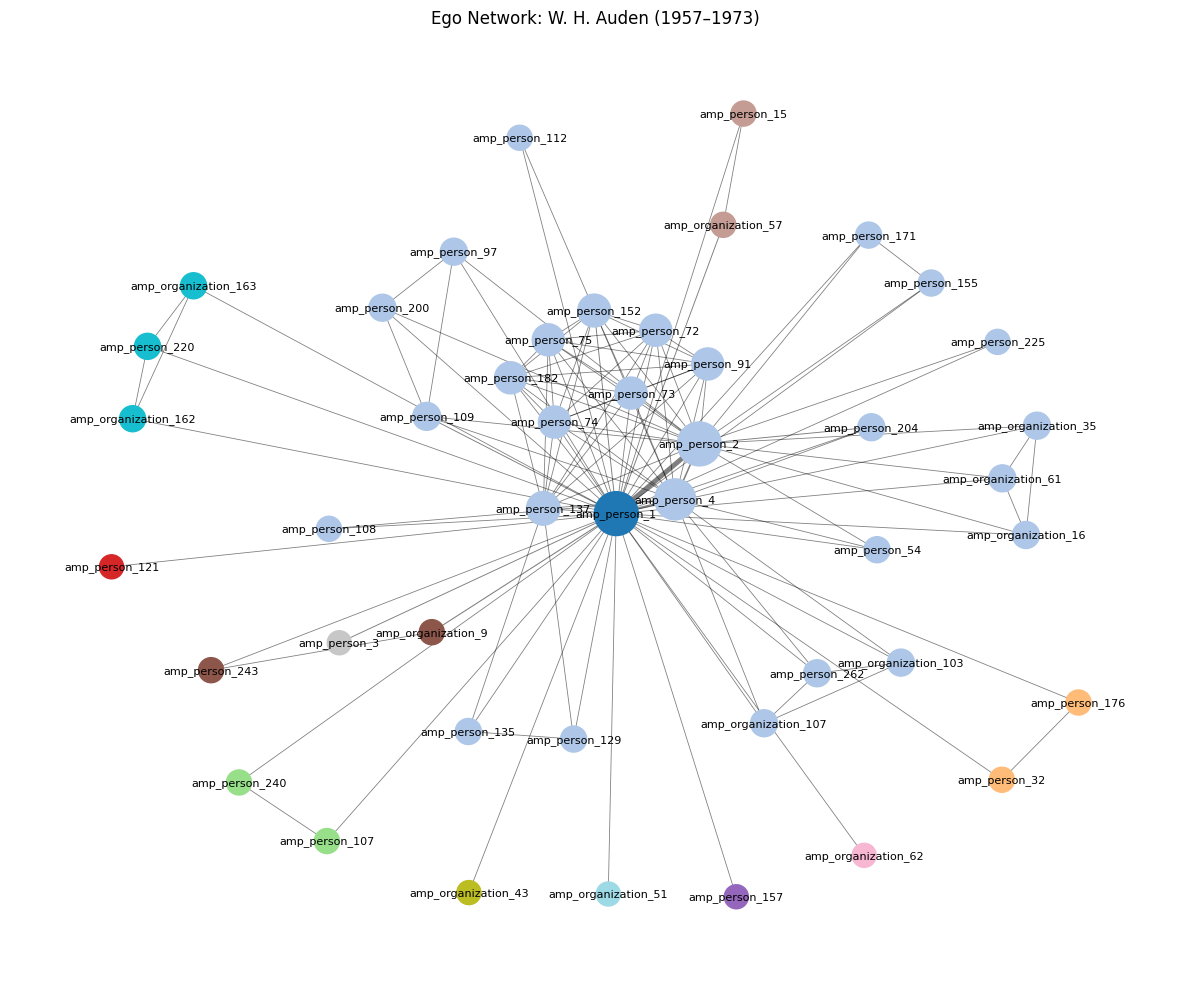

In [15]:
# Plot figure
plt.figure(figsize=(12, 10))  # Set dimensions to 12 by 10 inches
nx.draw_networkx_nodes(G_ego, pos, node_size=node_sizes, node_color=colors, cmap=plt.cm.tab20)  # Set node layout, sizes, and colors
nx.draw_networkx_edges(G_ego, pos, width=edge_widths, alpha=0.5)  # Set edge layout, widths, and transparency
nx.draw_networkx_labels(G_ego, pos, font_size=8)  # Set label layout and font size
plt.title("Ego Network: W. H. Auden (1957–1973)")
plt.axis('off')  # Hide coordinate axes
plt.tight_layout()  # Adjust margins so that the title and nodes don't get clipped
plt.show()  # Render and display the figure

#### Alternative visualization (Newman-weighted layout)

This alternative uses Newman's (2001) collaboration-weighted projection for layout only — each event's contribution to a pairwise edge weight is divided by `(k − 1)`, where `k` is event size, so single large events exert less pull on the spring algorithm. Edge thickness, node size, and coloring continue to use the simple-projection weights, keeping all reported numerical encodings consistent with the analytical section above.

In [16]:
G_newman = bipartite.collaboration_weighted_projected_graph(G_filtered_date, participants)

print(f"Nodes: {G_newman.number_of_nodes()}")
print(f"Edges: {G_newman.number_of_edges()}")

print("\nStrongest connections:")
edges_by_weight = sorted(G_newman.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
for u, v, d in edges_by_weight[:5]:
    print(f"  {u} — {v}: {d['weight']:.2f}")

Nodes: 62
Edges: 164

Strongest connections:
  amp_person_1 — amp_person_2: 27.60
  amp_person_4 — amp_person_1: 5.52
  amp_person_4 — amp_person_2: 2.77
  amp_person_1 — amp_organization_9: 2.50
  amp_person_1 — amp_person_3: 2.00


In [17]:
G_newman_ego = nx.ego_graph(G_newman, ego)

print(f"Alters: {G_newman_ego.number_of_nodes() - 1}")
print(f"Edges: {G_newman_ego.number_of_edges()}")

print("\nStrongest connections:")
edges_by_weight = sorted(G_newman_ego.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)
for u, v, d in edges_by_weight[:5]:
    print(f"  {u} — {v}: {d['weight']:.2f}")

Alters: 45
Edges: 129

Strongest connections:
  amp_person_1 — amp_person_2: 27.60
  amp_person_4 — amp_person_1: 5.52
  amp_person_4 — amp_person_2: 2.77
  amp_person_1 — amp_organization_9: 2.50
  amp_person_1 — amp_person_3: 2.00


In [18]:
pos_newman = nx.spring_layout(G_newman_ego, weight='weight', seed=42)

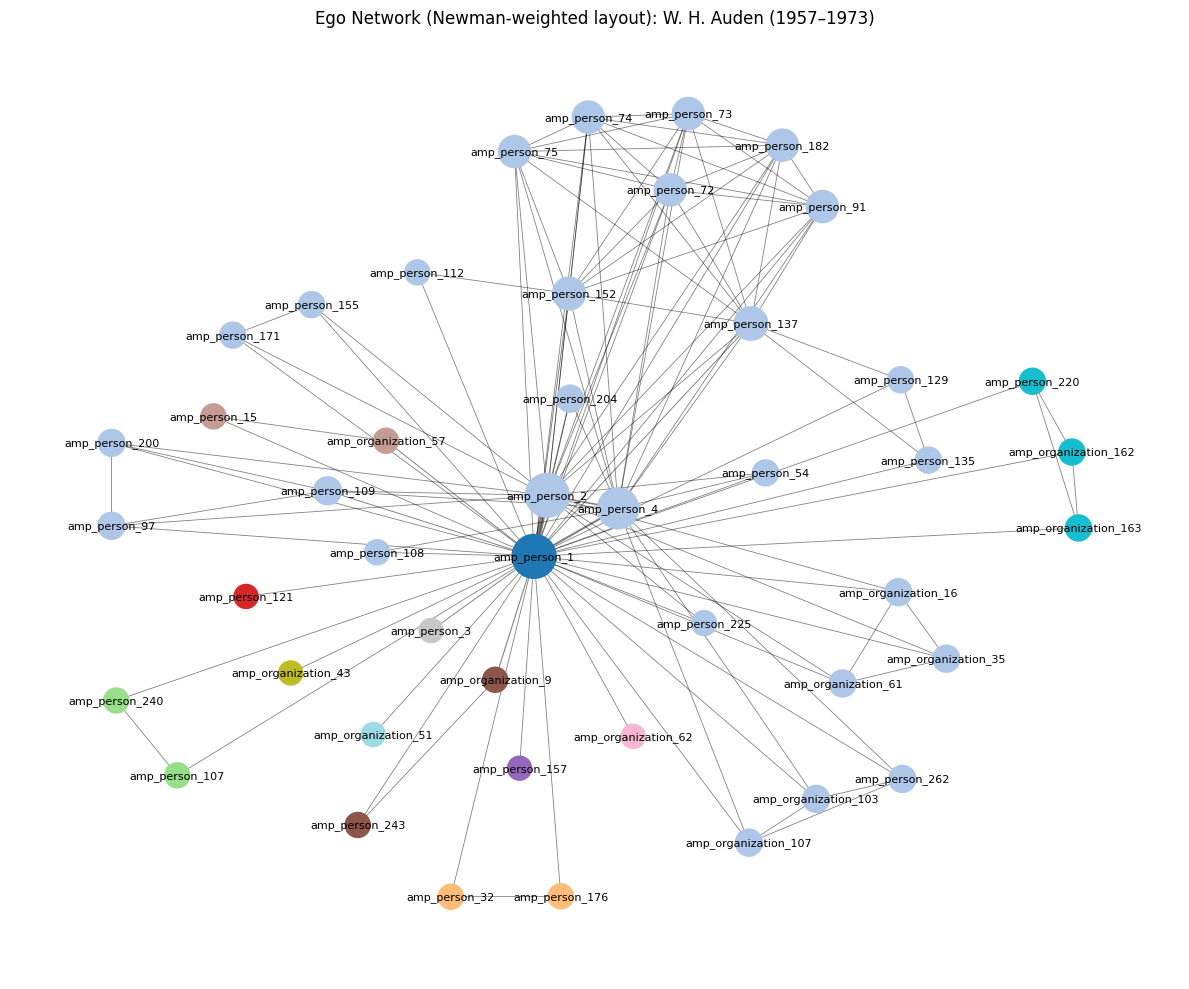

In [19]:
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G_ego, pos_newman, node_size=node_sizes, node_color=colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G_ego, pos_newman, width=edge_widths, alpha=0.5)
nx.draw_networkx_labels(G_ego, pos_newman, font_size=8)
plt.title("Ego Network (Newman-weighted layout): W. H. Auden (1957–1973)")
plt.axis('off')
plt.tight_layout()
plt.show()

#### Further variant (edge styling by weight)

This variant additionally distinguishes edge types. Edges with weight 1 (single co-affiliation) are drawn as faint dashed lines; edges with weight ≥ 2 (repeated co-affiliation) as solid lines with widths scaled to weight. Single-event clique groups still cluster spatially — a topological consequence of the projection that no layout choice can eliminate — but their edges are visually marked as single-occurrence rather than recurrent. Note: the visual jump between weight 1 and weight 2 overstates a one-event difference, trading one misreading for another.

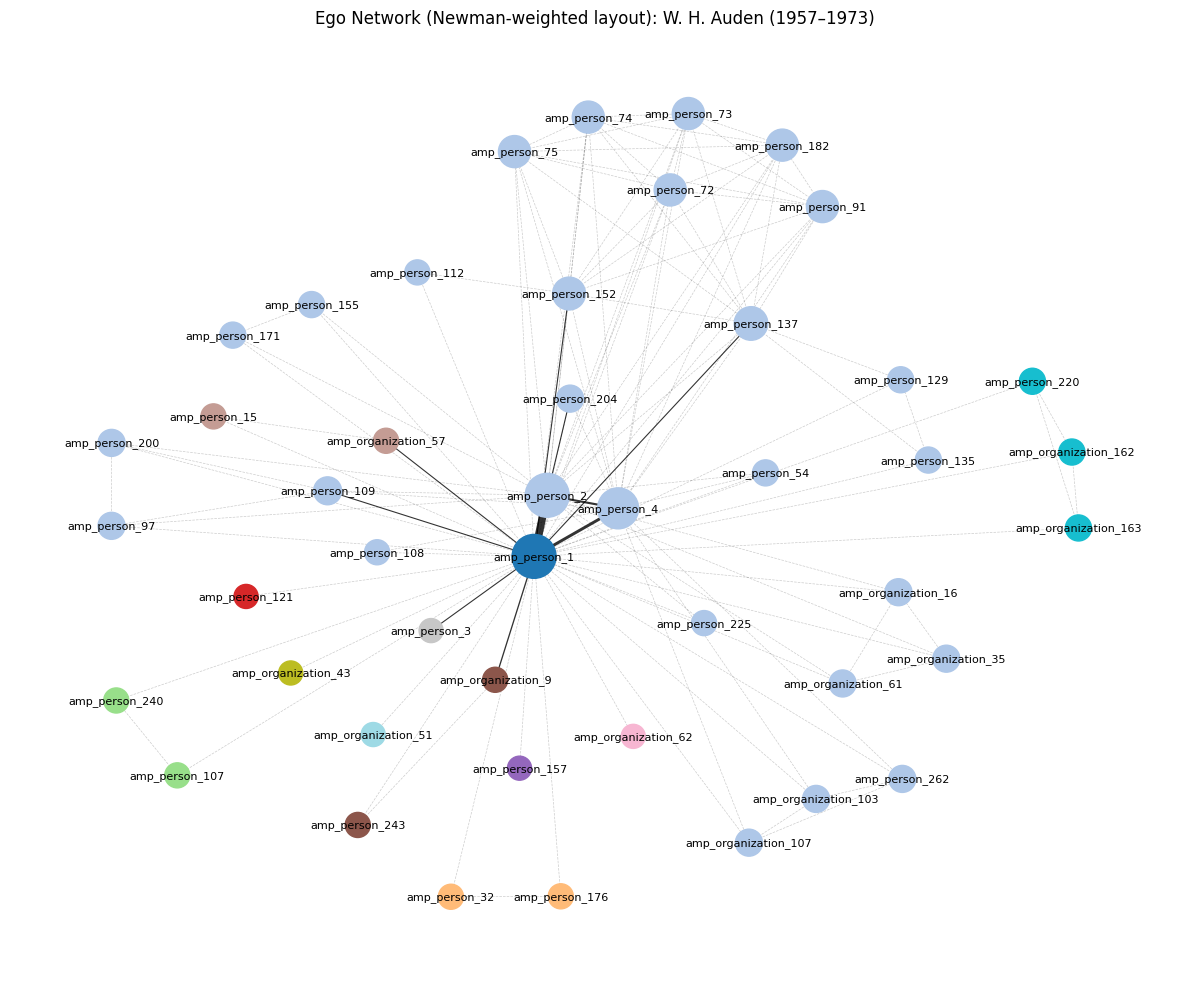

In [20]:
# Split edges by weight: weight 1 (single co-affiliation), weight >= 2 (repeated co-affiliation)
weak_edges = [(u, v) for u, v, d in G_ego.edges(data=True) if d['weight'] == 1]
strong_edges_data = [(u, v, d['weight']) for u, v, d in G_ego.edges(data=True) if d['weight'] >= 2]
strong_edges = [(u, v) for u, v, _ in strong_edges_data]

# Normalize strong-edge widths against max strong weight only
max_strong_weight = max((w for _, _, w in strong_edges_data), default=1)  # Fallback to 1 if no strong edges
strong_widths = [0.5 + 5 * (w / max_strong_weight) for _, _, w in strong_edges_data]

# Plot
plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(G_ego, pos_newman, node_size=node_sizes, node_color=colors, cmap=plt.cm.tab20)
nx.draw_networkx_edges(G_ego, pos_newman, edgelist=weak_edges, style='dashed', width=0.5, alpha=0.2)  # Weak: dashed, faint
nx.draw_networkx_edges(G_ego, pos_newman, edgelist=strong_edges, style='solid', width=strong_widths, alpha=0.8)  # Strong: solid, prominent
nx.draw_networkx_labels(G_ego, pos_newman, font_size=8)
plt.title("Ego Network (Newman-weighted layout): W. H. Auden (1957–1973)")
plt.axis('off')
plt.tight_layout()
plt.show()